<a href="https://colab.research.google.com/github/Atharva-Gaykar/Deep_Learning/blob/main/CHATBOT_TUMOR_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

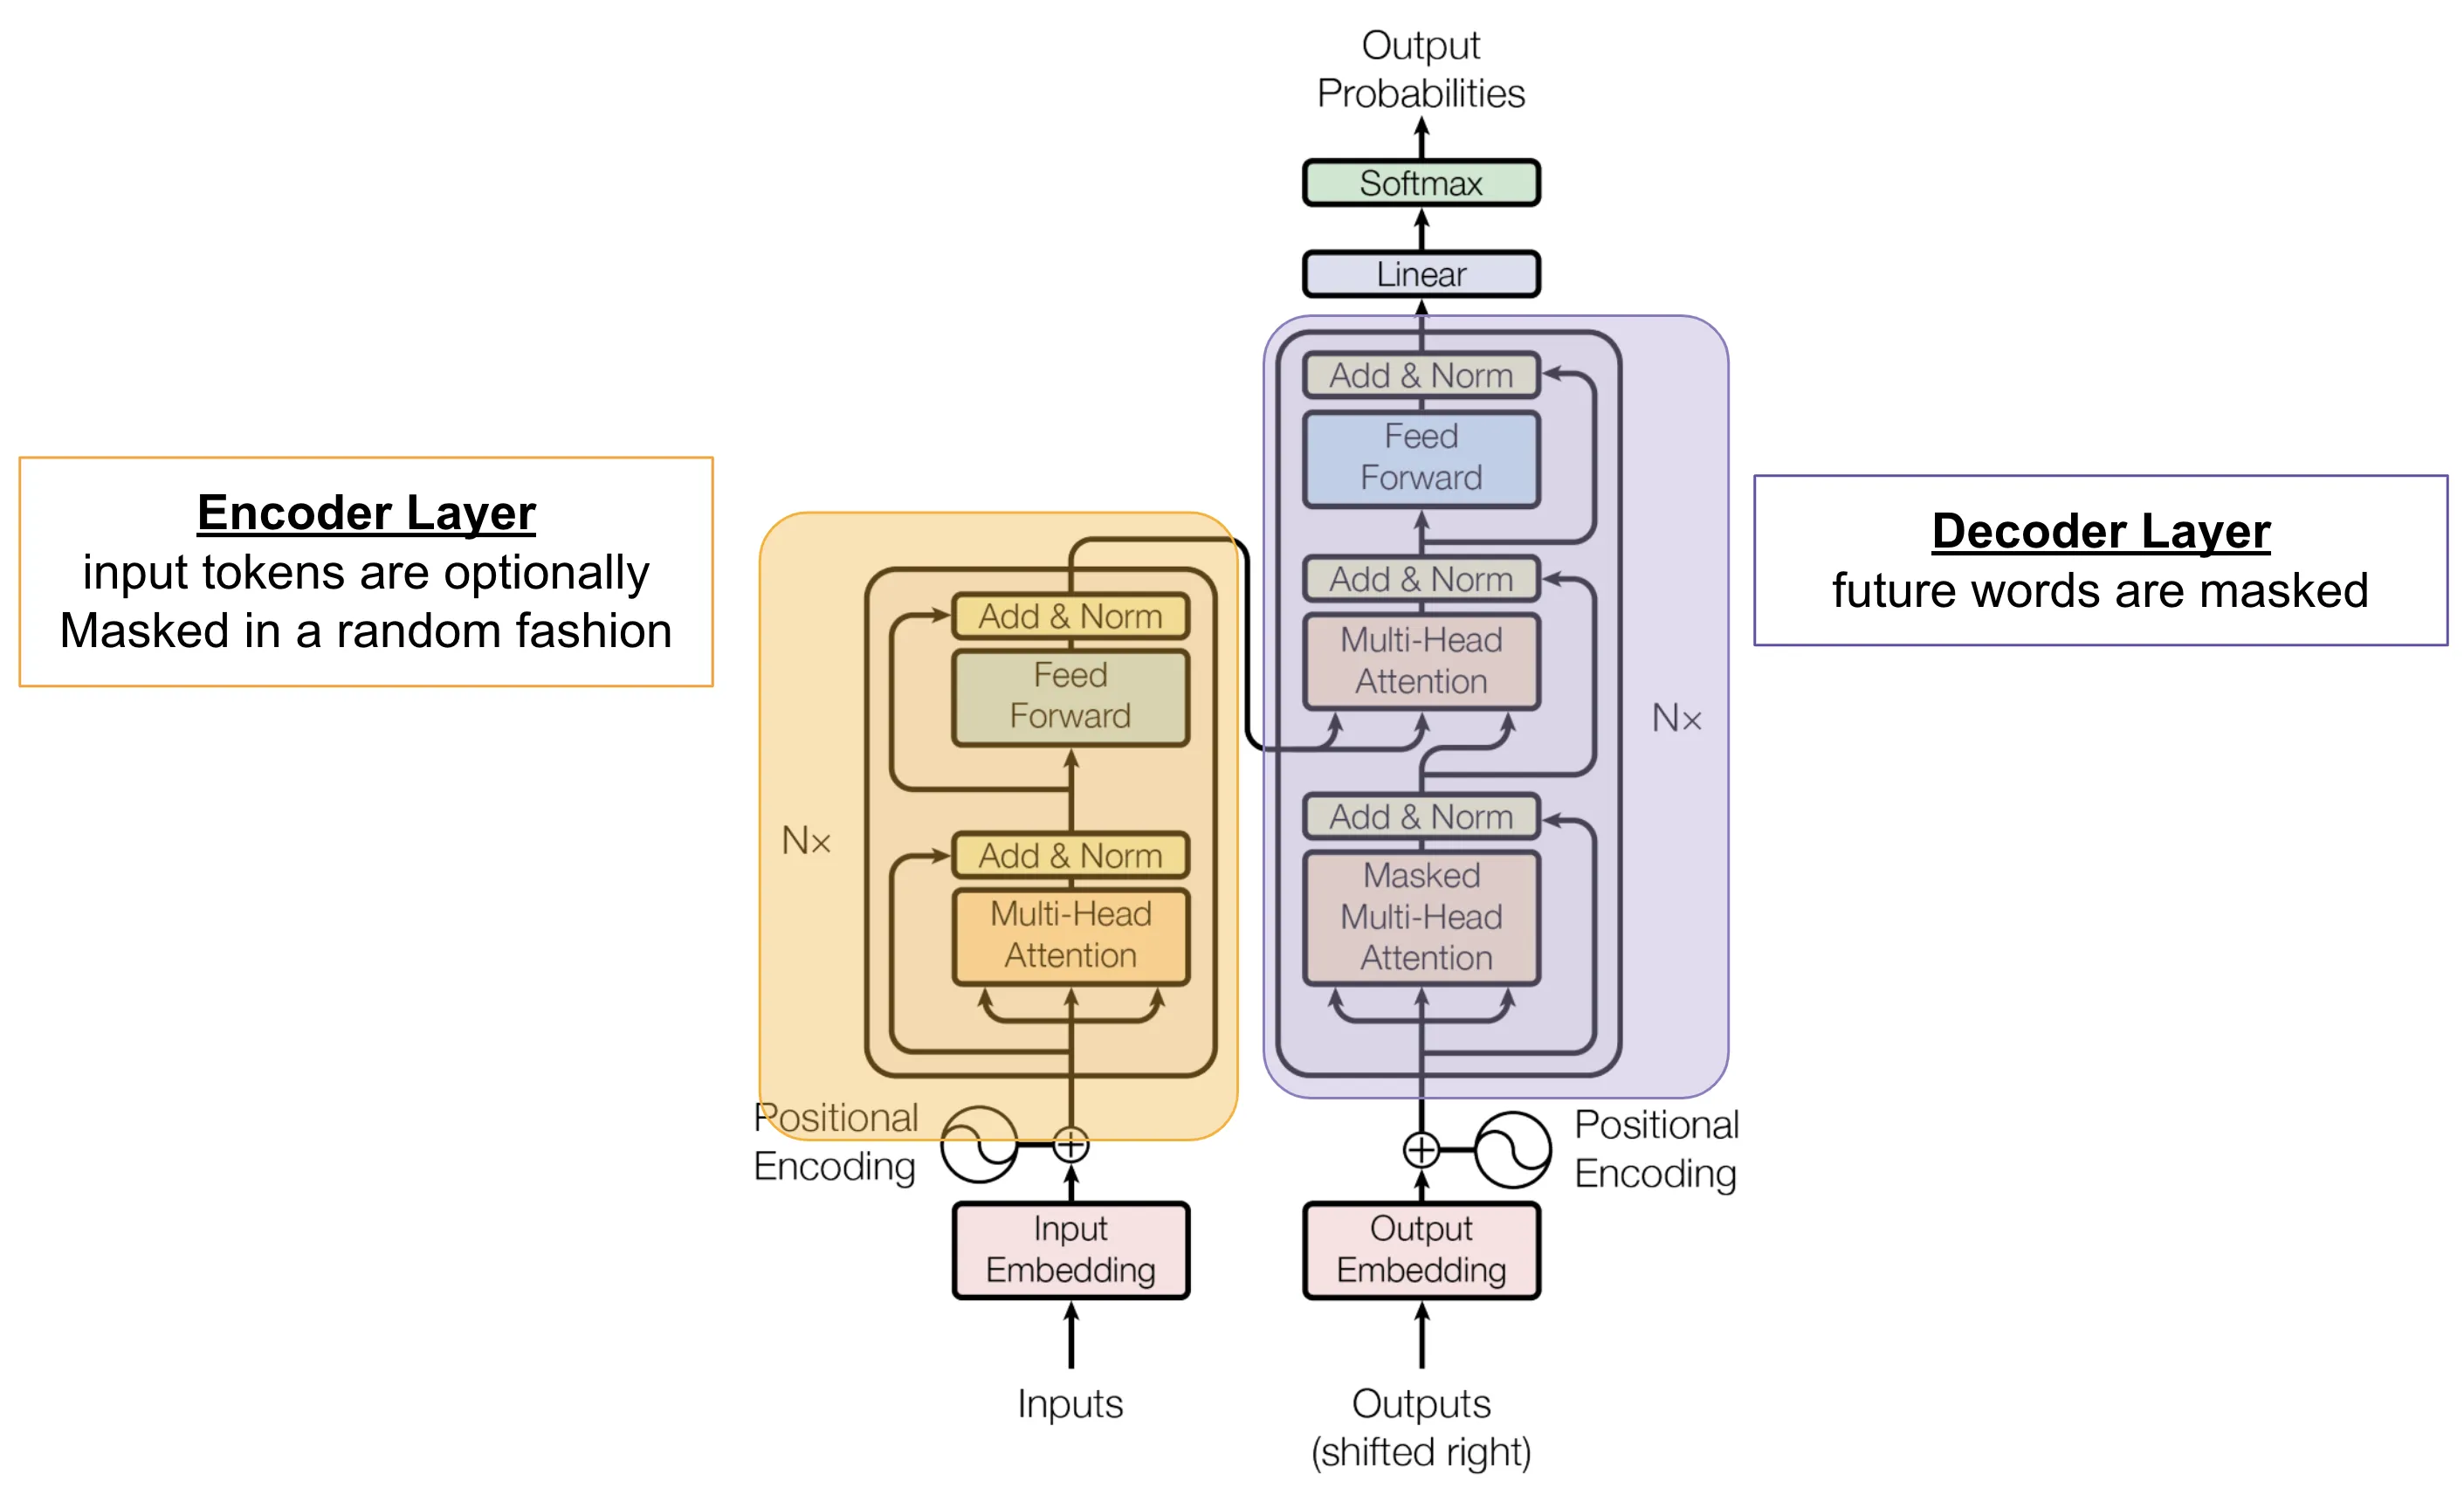



---

### 🔗 Data Source Collection for Brain Tumor Q\&A Chatbot

To construct the **2753 domain-specific question–answer pairs** for fine-tuning FLAN-T5 with LoRA, high-quality and medically credible information was curated from the following web sources:

#### 🧠 Source Websites:

1. [Difference Between Meningioma and Glioma – DryAshar](https://dryashar.com/blog/difference-between-meningioma-and-glioma/)
2. [NCBI – Central Nervous System Tumors Overview](https://www.ncbi.nlm.nih.gov/books/NBK441874/) *(used twice due to its detailed structured content)*
3. [Cleveland Clinic – Pituitary Adenomas](https://my.clevelandclinic.org/health/diseases/15328-pituitary-adenomas)
4. [Mayo Clinic – Glioma](https://www.mayoclinic.org/diseases-conditions/glioma/symptoms-causes/syc-20350251)
5. [Mayo Clinic – Meningioma](https://www.mayoclinic.org/diseases-conditions/meningioma/symptoms-causes/syc-20355643)
6. [Mayo Clinic – Pituitary Tumors](https://www.mayoclinic.org/diseases-conditions/pituitary-tumors/symptoms-causes/syc-20350548)

#### 🧾 Process:


---

* The QA data was then **formatted into `input` and `target` columns** and saved as a **CSV file** to prepare it for fine-tuning.
* This setup was designed for a **closed-book Q\&A generation task**, where the model learns to answer questions based solely on internalized knowledge without external reference at inference time.




---





---

🧠 **Through this project: Brain Tumor Q\&A Chatbot using FLAN-T5 with LoRA**

* The objective was to build a **domain-specific chatbot** that answers questions related to **brain tumors**.
* This was a **closed-book Q\&A task**, not a classification task.
* A total of **2,375 Q\&A pairs** were used, covering categories like *pituitary tumor, meningioma, glioma*, and general tumor-related queries.
* The model used was **FLAN-T5**, which was fine-tuned using the **LoRA (Low-Rank Adaptation)** method to reduce training cost while maintaining performance.
“Answer the question:” for each sample.
* This project demonstrated how **lightweight fine-tuning with LoRA** can create an effective medical assistant without training a large model from scratch.

---




**LoRA (Low-Rank Adaptation) in Attention Modules: Full Formula Reference**

---

### 🔍 Overview

LoRA is a parameter-efficient fine-tuning method where large pretrained model weights are frozen, and low-rank matrices are trained to adapt the model's behavior. It is primarily applied to linear layers such as those in the attention mechanism: Query (Q), Key (K), Value (V), and Output (O).

---

### 👉 LoRA Weight Injection

Given a frozen weight matrix $W \in \mathbb{R}^{d_{out} \times d_{in}}$, LoRA introduces two trainable low-rank matrices:

* $A \in \mathbb{R}^{r \times d_{in}}$
* $B \in \mathbb{R}^{d_{out} \times r}$
* $r \ll \min(d_{out}, d_{in})$

The update to the base weight is:

$$
\Delta W = \frac{\alpha}{r} \cdot B A
$$

The effective weight becomes:

$$
W_{\text{effective}} = W + \frac{\alpha}{r} \cdot BA
$$

---

### 📊 Forward Pass with LoRA

Let $X \in \mathbb{R}^{\text{batch} \times d_{in}}$ be the input to a linear layer.

#### ✨ Without LoRA:

$$
Y = X W^T
$$

#### ✨ With LoRA:

$$
Y = X W^T + \frac{\alpha}{r} X A^T B^T
$$

---

### 🏋️️ Training Behavior

* The **loss is computed using the full output** (i.e., $Y$)
* Gradients flow through $A$ and $B$ only
* The base weight $W$ is frozen and does not receive gradients

---

### 🔄 LoRA Applied to Attention Components

Assume the attention uses the following projections:

* $Q = X W_Q^T$
* $K = X W_K^T$
* $V = X W_V^T$
* $O = H W_O^T$, where $H = \text{Attention}(Q, K, V)$

Each of these can be modified with LoRA as follows:

#### 🔹 Query (Q):

$$
Q = X W_Q^T + \frac{\alpha}{r} X A_Q^T B_Q^T
$$

#### 🔹 Key (K):

$$
K = X W_K^T + \frac{\alpha}{r} X A_K^T B_K^T
$$

#### 🔹 Value (V):

$$
V = X W_V^T + \frac{\alpha}{r} X A_V^T B_V^T
$$

#### 🔹 Output (O):

$$
O = H W_O^T + \frac{\alpha}{r} H A_O^T B_O^T
$$

---

### 📊 Summary Table

| Component | LoRA Formula                                  |
| --------- | --------------------------------------------- |
| Q         | $Q = XW_Q^T + \frac{\alpha}{r} X A_Q^T B_Q^T$ |
| K         | $K = XW_K^T + \frac{\alpha}{r} X A_K^T B_K^T$ |
| V         | $V = XW_V^T + \frac{\alpha}{r} X A_V^T B_V^T$ |
| O         | $O = HW_O^T + \frac{\alpha}{r} H A_O^T B_O^T$ |

---

### ⚖️ Scaling Factor Explanation

* $\alpha$ is a hyperparameter (e.g., 8, 16, etc.)
* $r$ is the LoRA rank (low-rank dimension)
* $\frac{\alpha}{r}$ controls how much the LoRA update contributes relative to the base weight
* If $\alpha = r$: no scaling
* If $\alpha < r$: smaller update
* If $\alpha > r$: stronger adaptation


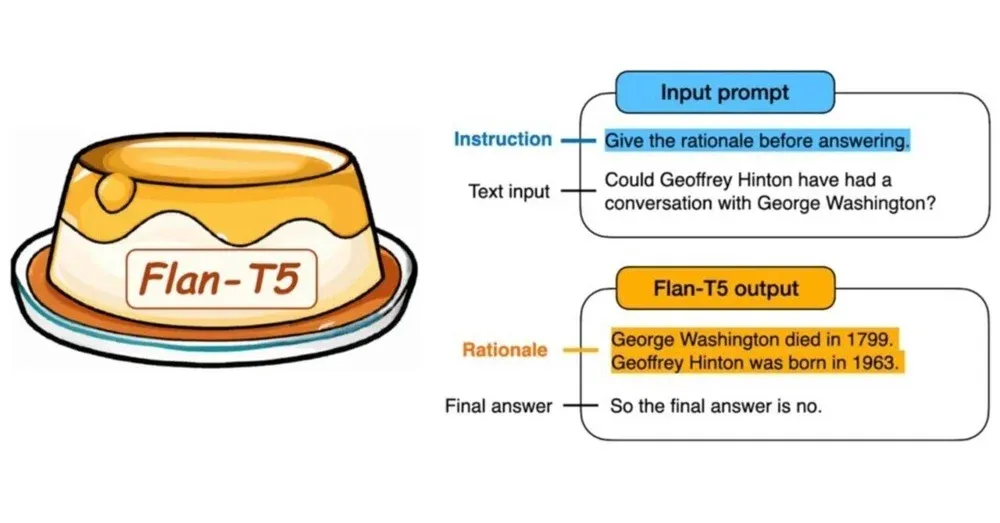



---

### 📌 **FLAN-T5 Base: Key Information**

* **Model Type**: Text-to-text Transformer (encoder-decoder architecture).
* **Base Model**: Built on top of **T5 (Text-To-Text Transfer Transformer)** architecture.
* **Fine-Tuned On**: FLAN-T5 is a *instruction-tuned* version of T5 trained on a mix of tasks (summarization, QA, translation, etc.).
* **Parameter Count**:
  🧠 **FLAN-T5 Base** has **250 million** parameters.
* **Input/Output Format**:
  Takes in a string prompt like: `"Answer the following question: What is a glioma?"`
  And outputs the predicted string answer.
* **Training Style**:
  Instruction tuning — it learns better from prompts that start with an instruction (e.g., "Translate...", "Summarize...", "Answer the question...").
* **Tokenizer**:
  Uses a **SentencePiece** tokenizer trained on a 32k vocabulary.
* **Encoder-Decoder Stack**:

  * **12 encoder layers**
  * **12 decoder layers**
  * **Hidden size**: 768
  * **Attention heads**: 12
  * **Max input length**: typically 512 tokens
* **Use Case Fit**:
  Especially well-suited for **multi-task learning**, **question answering**, **summarization**, **translation**, and **instruction-based prompts**.

---





---

### 📘 Here's the distinction and how FLAN-T5 fits:

#### 🔒 **Closed-Book QA**:

* **Definition**: Model must answer questions **without external documents or context at inference time**.
* **FLAN-T5 excels here** because:

  * It has been instruction-tuned on massive QA datasets like **Natural Questions**, **TriviaQA**, and **SQuAD**, where the model learns to recall and reason from **its internal knowledge**.
  * Works great for domain-specific chatbot tasks (like my brain tumor Q\&A project) where the model learns answers during fine-tuning.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


import pandas as pd

work_dt= pd.read_csv('/content/drive/MyDrive/final_df.csv')


In [ ]:


work_dt_val= pd.read_csv('/content/drive/MyDrive/work_dt_val.csv')

In [ ]:
work_dt.head(5)

,input,target
0,What are the treatment options for pituitary t...,Treatment includes observation for small tumor...
1,What therapeutic approaches are available for ...,Treatment includes observation for small tumor...
2,How are pituitary gland tumors managed medically?,Treatment includes observation for small tumor...
3,Which treatment modalities work best for pitui...,Treatment includes observation for small tumor...
4,How do doctors treat pituitary adenomas?,Treatment approaches depend on tumor type: pro...


In [ ]:
work_dt_val.head(5)

,input,target
0,List at least three risk factors associated wi...,Three risk factors for glioma include increasi...
1,How can symptoms like seizures and speech diff...,Gliomas can press on or invade areas of the br...
2,Which treatment modalities are commonly used f...,Treatment for high-grade gliomas typically inc...
3,What is the origin of meningiomas in the brain?,Meningiomas originate from the arachnoid cap c...
4,Why are women more likely to develop meningiomas?,Women are more likely to develop meningiomas d...


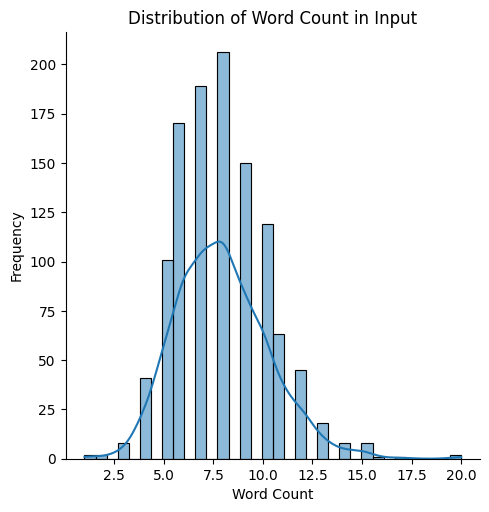

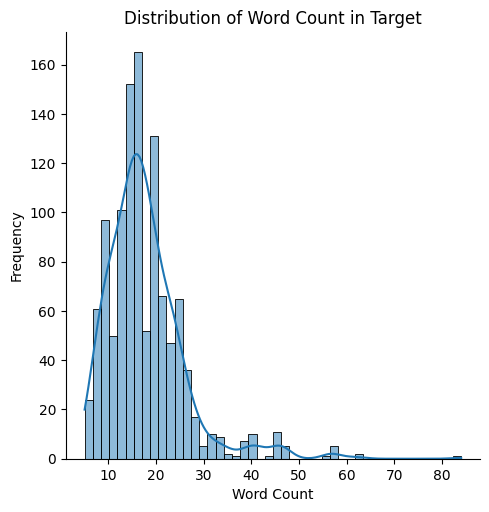

In [ ]:


import seaborn as sns
import matplotlib.pyplot as plt

work_dt['input_word_count'] = work_dt['input'].apply(lambda x: len(str(x).split()))
work_dt['target_word_count'] = work_dt['target'].apply(lambda x: len(str(x).split()))

sns.displot(work_dt['input_word_count'], kde=True)
plt.title('Distribution of Word Count in Input')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()
print('\n')

sns.displot(work_dt['target_word_count'], kde=True)
plt.title('Distribution of Word Count in Target')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()


In [ ]:
list_dr=['input_word_count','target_word_count']
work_dt=work_dt.drop(list_dr,axis=1)

In [ ]:
from datasets import Dataset

In [ ]:
dataset = Dataset.from_pandas(work_dt)
dataset = dataset.remove_columns(['__index_level_0__']) if '__index_level_0__' in dataset.column_names else dataset

In [ ]:
dataset_val = Dataset.from_pandas(work_dt_val)
dataset_val = dataset_val.remove_columns(['__index_level_0__']) if '__index_level_0__' in dataset_val.column_names else dataset_val

In [ ]:
dataset

Dataset({
    features: ['input', 'target'],
    num_rows: 1134
})

In [ ]:
%pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
import nltk
from datasets import load_dataset
import evaluate
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, TrainingArguments, Trainer, DataCollatorForSeq2Seq
from datasets import load_dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
from peft import get_peft_model, LoraConfig, TaskType
from transformers import T5ForConditionalGeneration

base_model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-small")

lora_config = LoraConfig(
    r=8,
    lora_alpha=24,
    target_modules=["k", "q", "v"],  # You can also use ["k", "q", "v", "o"] for deeper tuning
    lora_dropout=0.01,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 516,096 || all params: 77,477,248 || trainable%: 0.6661


In [ ]:


data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

In [ ]:
prefix = "answer the question: "
def preprocess_function(examples):
    inputs = [prefix + text for text in examples["input"]] if prefix else examples["input"]

    model_inputs = tokenizer(
        inputs,
        max_length=30,
        truncation=True,
        padding="max_length"
    )

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples["target"],
            max_length=100,
            truncation=True,
            padding="max_length"
        )

    # Replace pad tokens with -100 safely
    labels["input_ids"] = [
        [token if token != tokenizer.pad_token_id else -100 for token in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs



In [ ]:
tokenized_dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/1134 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:4006: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [ ]:
tokenized_dataset_val = dataset_val.map(preprocess_function, batched=True)

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

In [ ]:
pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=ed8041b22c0fef77e76cd4195d7710ffe6d59be7362a395660299613bc58d97f
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [ ]:
import numpy as np
import nltk
import evaluate
nltk.download("punkt", quiet=True)

rouge = evaluate.load("rouge")
import numpy as np
import evaluate

rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Replace -100 with pad_token_id so we can decode properly
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Decode predictions and labels
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Skip sentence tokenization to avoid nltk error
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    # Compute ROUGE
    return rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )



---

### 🧮 `compute_metrics` Function Explanation (for Evaluation)

* ✅ **Handles label padding**:
  Replaces `-100` (used to ignore tokens in loss computation) with `tokenizer.pad_token_id` so labels can be correctly decoded.

* 🔁 **Decodes predictions and labels**:
  Converts token IDs back to readable strings using `tokenizer.batch_decode` and removes special tokens.

* 🧹 **Cleans text before evaluation**:
  Trims whitespace from each decoded string for consistent evaluation.

* 📏 **Evaluates using ROUGE metric**:
  Uses the ROUGE score (with stemming) to compare predicted sequences against ground truth references.

* 🚫 **Avoids sentence tokenization step**:
  Skips sentence splitting (to prevent issues like missing `punkt` tokenizer from `nltk`) and simplifies pipeline.

---



In [ ]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate= 2e-4 ,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=6,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=10,
    predict_with_generate=True,
    logging_strategy="steps",
    logging_steps=5,
    logging_first_step=True,
    disable_tqdm=False,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    report_to="none",
    push_to_hub=False
)



In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    eval_dataset=tokenized_dataset_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,

)




/tmp/ipython-input-112644361.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


1.80

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.415400,2.285051,0.371792,0.168429,0.315969,0.314626
2,2.301900,2.287991,0.363197,0.160615,0.306212,0.305270
3,1.920500,2.275385,0.376202,0.160848,0.310076,0.309908
4,2.286400,2.273655,0.370379,0.157634,0.305499,0.304722
5,2.107600,2.274034,0.370379,0.157634,0.305499,0.304722
6,1.991600,2.270663,0.370379,0.157634,0.305499,0.304722
7,2.099000,2.271762,0.366891,0.157634,0.305499,0.304722
8,2.079700,2.273061,0.369933,0.157516,0.304646,0.303788
9,1.977900,2.268148,0.355366,0.158628,0.306781,0.305705
10,1.984700,2.270041,0.357007,0.159720,0.303970,0.303346


TrainOutput(global_step=1420, training_loss=2.1666396762283755, metrics={'train_runtime': 198.2531, 'train_samples_per_second': 57.2, 'train_steps_per_second': 7.163, 'total_flos': 124568981913600.0, 'train_loss': 2.1666396762283755, 'epoch': 10.0})

In [ ]:
# Glioma
glioma_symptoms = [
    "What are the symptoms of a glioma tumor?",
    "How does glioma affect cognitive or motor functions?",
    "Can glioma cause seizures or headaches?"
]

glioma_causes = [
    "What causes glioma to develop?",
    "Are there genetic risk factors for glioma?",
    "Is radiation exposure linked to glioma formation?"
]

glioma_treatment = [
    "What are the treatment options for glioma?",
    "How effective is surgery for glioma?",
    "Can glioma be treated with chemotherapy or radiation?",
    "What is the prognosis after glioma treatment?"
]

# Meningioma
meningioma_symptoms = [
    "What are the symptoms of meningioma?",
    "Can meningioma cause vision or hearing problems?",
    "Are meningiomas usually symptomatic or silent?"
]

meningioma_causes = [
    "What causes meningioma tumors?",
    "Is there a hormonal link to meningioma development?",
    "Are meningiomas hereditary?"
]

meningioma_treatment = [
    "What are the treatment options for meningioma?",
    "Is surgery always required for meningioma?",
    "Can meningioma be treated with radiosurgery?",
    "What is the recurrence rate after meningioma treatment?"
]

# Pituitary Tumor
pituitary_symptoms = [
    "What are the symptoms of a pituitary tumor?",
    "Can pituitary tumors affect hormone levels?",
    "Do pituitary tumors cause vision changes?"
]

pituitary_causes = [
    "What causes pituitary tumors?",
    "Are pituitary tumors related to endocrine disorders?",
    "Can pituitary tumors be inherited?"
]

pituitary_treatment = [
    "What are the treatment options for pituitary tumors?",
    "Is medication effective for treating pituitary tumors?",
    "When is surgery recommended for pituitary tumors?",
    "Can pituitary tumors be treated with hormone therapy?"
]

In [ ]:
import torch

# ✅ Your input question
question = "what are treatments given for brain tumors?"
prefix = "answer the question: "  # remove this if you didn't use it during training
input_text = prefix + question

# ✅ Tokenize the input
inputs = tokenizer(input_text, return_tensors="pt", padding=True).to(model.device)

# ✅ Generate output
model.eval()
with torch.no_grad():
  output = model.base_model.generate(
    inputs["input_ids"],
    max_new_tokens=100,
    do_sample=False,
    temperature=0.0)



# ✅ Decode and print answer
answer = tokenizer.decode(output[0], skip_special_tokens=True)
print("Answer:", answer)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Answer: Treatment for brain tumors is based on the tumor type, a tumor that is causing symptoms, and a tumor that is causing symptoms.


In [ ]:
import torch

# ✅ Combine all questions into one list
all_questions = glioma_symptoms + glioma_causes + glioma_treatment + \
                meningioma_symptoms + meningioma_causes + meningioma_treatment + \
                pituitary_symptoms + pituitary_causes + pituitary_treatment

# ✅ Optional prefix (remove if not used during training)
prefix = "answer the question: "

# ✅ Set model to evaluation mode
model.eval()

# ✅ Loop through each question
for question in all_questions:
    input_text = prefix + question
    inputs = tokenizer(input_text, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
        output = model.base_model.generate(
            inputs["input_ids"],
            max_new_tokens=100,
            do_sample=False,
            temperature=0.0
        )

    answer = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Q: {question}\nA: {answer}\n{'-'*60}")



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: What are the symptoms of a glioma tumor?
A: The symptoms of a glioma tumor include a headache, nausea, vomiting, and a headache.
------------------------------------------------------------


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: How does glioma affect cognitive or motor functions?
A: Glioma affects cognitive or motor functions by affecting the brain and spinal cord.
------------------------------------------------------------


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

Q: What are the treatment options for pituitary tumors?
A: Treatment options include surgery, radiation therapy, and chemotherapy.
------------------------------------------------------------


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: Is medication effective for treating pituitary tumors?
A: Yes, medication is effective for treating pituitary tumors.
------------------------------------------------------------


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: When is surgery recommended for pituitary tumors?
A: Surgery is recommended for pituitary tumors when they are asymptomatic.
------------------------------------------------------------
Q: Can pituitary tumors be treated with hormone therapy?
A: Yes, pituitary tumors can be treated with hormone therapy.
------------------------------------------------------------


In [ ]:

log_history = trainer.state.log_history

train_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]
eval_logs = [log for log in log_history if 'eval_loss' in log]

# Extract epochs, training losses, and validation losses
epochs = [log['epoch'] for log in eval_logs]
train_losses = [log['loss'] for log in train_logs if 'loss' in log]
eval_losses = [log['eval_loss'] for log in eval_logs]

aligned_train_losses = []
eval_epochs = [log['epoch'] for log in eval_logs]
train_epochs = [log['epoch'] for log in train_logs if 'loss' in log] # These are actually steps as epoch can be float

epochs_plot = []
train_loss_plot = []
eval_loss_plot = []

for log in log_history:
    if 'loss' in log and 'eval_loss' not in log:
        if log['epoch'] not in [entry[0] for entry in train_loss_plot]:
             train_loss_plot.append((log['epoch'], log['loss']))
    elif 'eval_loss' in log:
        epochs_plot.append(log['epoch'])
        eval_loss_plot.append(log['eval_loss'])

train_loss_plot.sort(key=lambda x: x[0])
aligned_train_loss_plot = [loss for epoch, loss in train_loss_plot if epoch in epochs_plot]

epochs_for_plot = []
train_losses_for_plot = []
eval_losses_for_plot = []
current_train_loss = None

for log in log_history:
    if 'loss' in log and 'eval_loss' not in log:
        current_train_loss = log['loss'] # Keep track of the last training loss
    elif 'eval_loss' in log:
        if current_train_loss is not None:
            epochs_for_plot.append(log['epoch'])
            train_losses_for_plot.append(current_train_loss)
            eval_losses_for_plot.append(log['eval_loss'])
            current_train_loss = None # Reset after recording

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_for_plot, train_losses_for_plot, label='Training Loss')
plt.plot(epochs_for_plot, eval_losses_for_plot, label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# You can also plot other metrics like ROUGE scores
rouge_L_scores = [log['eval_rougeL'] for log in eval_logs if 'eval_rougeL' in log]

if rouge_L_scores:
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, rouge_L_scores, label='Validation RougeL Score')
    plt.title('Validation RougeL Score per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('RougeL Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Add plots for other ROUGE scores if desired
rouge_1_scores = [log['eval_rouge1'] for log in eval_logs if 'eval_rouge1' in log]
rouge_2_scores = [log['eval_rouge2'] for log in eval_logs if 'eval_rouge2' in log]

if rouge_1_scores:
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, rouge_1_scores, label='Validation Rouge1 Score')
    plt.title('Validation Rouge1 Score per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Rouge1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

if rouge_2_scores:
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, rouge_2_scores, label='Validation Rouge2 Score')
    plt.title('Validation Rouge2 Score per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Rouge2 Score')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
# Suppose you used Hugging Face Trainer + PEFT
from transformers import T5Tokenizer
from peft import PeftModel

model_path = "/content/drive/MyDrive/tumor_chat_model"
model.save_pretrained(model_path)         # <-- CRUCIAL for LoRA
tokenizer.save_pretrained(model_path)          # optional if you're using custom tokens


('/content/drive/MyDrive/tumor_chat_model/tokenizer_config.json',
 '/content/drive/MyDrive/tumor_chat_model/special_tokens_map.json',
 '/content/drive/MyDrive/tumor_chat_model/tokenizer.json')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from peft import PeftModel
from transformers import AutoTokenizer, T5ForConditionalGeneration
import torch

model_path = "/content/drive/MyDrive/tumor_chat_model"

# Load the base model
base_model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")

# Load the PEFT model (which contains the LoRA weights)
model = PeftModel.from_pretrained(base_model, model_path)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Move the model to the appropriate device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded from {model_path} and moved to {device}.")

Model loaded from /content/drive/MyDrive/lora_chat_model and moved to cuda.


In [ ]:
import torch

# ✅ Your input question
question = "Why do gliomas form?"
prefix = "answer the question: "  # remove this if you didn't use it during training
input_text = prefix + question

# ✅ Tokenize the input
inputs = tokenizer(input_text, return_tensors="pt", padding=True).to(model.device)

# ✅ Generate output
model.eval()
with torch.no_grad():
  output = model.base_model.generate(
    inputs["input_ids"],
    max_new_tokens=90,
    do_sample=False,
    temperature=0.0)



# ✅ Decode and print answer
answer = tokenizer.decode(output[0], skip_special_tokens=True)
print("Answer:", answer)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Answer: Gliomas form because they are a type of tumor that grows in the brain.


In [ ]:
same_meaning=[
    "What are the cause of glioma tumor?",
    "What triggers the development of glioma?",
    "Why do glioma form?"

]


---

### ✅ Why Encoder-Decoder Models (e.g., Flan-T5, BART) Are Better for Factual Recall in Fine-Tuned Q\&A Tasks

#### 📌 Architectural Advantages:

* **Bi-directional Encoder**:

  * Fully understands the question by attending to both past and future tokens.
  * Builds a rich, contextualized embedding of the question.
* **Cross-Attentive Decoder**:

  * Generates answers by referencing the encoder's representation of the question at every step.
  * Maintains a strong link between question and answer.

#### 📌 Benefits for Factual QA:

1. **🧠 Deep Input Understanding**
   The encoder creates a complete semantic representation of the question, which is essential for pinpointing the factual information being asked.

2. **🎯 Strong Input-Output Grounding**
   Cross-attention ensures each output token is guided by the original input, minimizing hallucination and keeping answers relevant.

3. **📏 Suitable for Asymmetric Tasks**
   Ideal for tasks where input and output sequences differ in structure or length — like question vs. answer.

4. **🛡️ Lower Risk of Hallucination**
   Since generation is grounded in encoded input, responses are less likely to go off-topic.

---

### ⚠️ Limitations of Decoder-Only Models (e.g., GPT-3, LLaMA, Mistral)

#### 📌 Architectural Constraints:

* **No Encoder**:

  * Input (question) and output (answer) are part of the same sequence.
  * Processes tokens autoregressively with **causal masking** — only attends to previous tokens.

#### 📌 Downsides for Factual QA:

1. **📉 Weaker Input Comprehension**
   Lacks dedicated bi-directional encoding of input; understanding is unidirectional and context-dependent.

2. **🔗 Loose Input-Output Coupling**
   Treats answer generation as sequence continuation, not direct mapping from question → answer.

3. **💬 Prone to Text Flow, Not Factual Anchoring**
   Can generate fluent but fabricated answers, especially if the fact isn't strongly present in training.

4. **📦 Historical Context Window Limits**
   While newer models have larger context windows, earlier models struggled with long or complex inputs.

---

### 🏁 Conclusion:

For **factual, domain-specific Q\&A** (like in your brain tumor chatbot or Shivaji Maharaj project), fine-tuning an **encoder-decoder model like Flan-T5 with LoRA** is:

* ✅ **A smart choice**, especially when the task demands precision.
* ✅ **Aligned with the model’s natural strength** in input-output mapping and grounding answers to input.
* ✅ **Likely to produce better recall accuracy** on structured, curated Q\&A datasets.

---

